In [1]:
# ==============================================================
# COMPLETE PIPELINE — FRB Isotropy Test
# WITH JACKKNIFE UNCERTAINTIES (CONSISTENT)
# ==============================================================

import numpy as np
import pandas as pd
import treecorr
import healpy as hp
import os
from tqdm.auto import tqdm
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ks_2samp
import seaborn as sns

In [2]:
# ==============================================================
# 1. GENERAL CONFIGURATIONS
# ==============================================================

BASE_PATH = "/home/brunowesley/projetos/FRB-isotropy-tests/FRB_catalogs/"

NORTH_PATHS = [os.path.join(BASE_PATH, f"SkyPosition_North{i}.csv")
               for i in range(1, 16)]
SOUTH_PATH = os.path.join(BASE_PATH, "SkyPosition_South.csv")

N_RAND_FACTOR = 20
N_MOCKS = 200

USE_GAL_MASK = True
GAL_CUT = 20.0

USE_LOG = False
MAX_SEP = 180.0
MIN_SEP = 0.1

if USE_LOG:
    BIN_TYPE = 'Log'
    N_BINS = 20
else:
    BIN_TYPE = 'Linear'
    BIN_SIZE = 1.8
    N_BINS = int((MAX_SEP - MIN_SEP) / BIN_SIZE)

COARSE_BINS = np.arange(0, 181, 20)
COARSE_CENTERS = 0.5 * (COARSE_BINS[:-1] + COARSE_BINS[1:])

In [3]:
# ==============================================================
# 2. MASK FUNCTION
# ==============================================================

def apply_mask(df):
    """
    Apply:
    - coordinate cuts
    - optional Galactic mask
    """
    mask = (
        (df["RA"] >= 0) & (df["RA"] <= 360) &
        (df["DEC"] >= -90) & (df["DEC"] <= 90)
    )

    df = df[mask].copy()

    if USE_GAL_MASK:
        coords = SkyCoord(
            ra=df['RA'].values * u.degree,
            dec=df['DEC'].values * u.degree,
            frame='icrs'
        )
        b = coords.galactic.b.degree
        df = df[np.abs(b) > GAL_CUT]

    return df.reset_index(drop=True)


# ==============================================================
# 3. ISOTROPIC CATALOG
# ==============================================================

def generate_isotropic_catalog(n, seed=None):
    """
    Generate isotropic sky (uniform on sphere)
    """
    rng = np.random.default_rng(seed)
    ra = 360.0 * rng.random(n)
    dec = np.degrees(np.arcsin(2.0 * rng.random(n) - 1.0))
    return pd.DataFrame({"RA": ra, "DEC": dec})

In [4]:
# ==============================================================
# 4. 2pACF (LANDY–SZALAY)
# ==============================================================

def compute_2pacf(df_data, df_rand, log_spacing=False):

    cat_data = treecorr.Catalog(
        ra=df_data["RA"], dec=df_data["DEC"],
        ra_units="deg", dec_units="deg"
    )

    cat_rand = treecorr.Catalog(
        ra=df_rand["RA"], dec=df_rand["DEC"],
        ra_units="deg", dec_units="deg"
    )

    bin_type = 'Log' if log_spacing else 'Linear'

    corr = treecorr.NNCorrelation(
        min_sep=MIN_SEP,
        max_sep=MAX_SEP,
        nbins=N_BINS,
        sep_units="deg",
        metric='Arc',
        bin_type=bin_type
    )

    rr = treecorr.NNCorrelation(**corr.config)
    dr = treecorr.NNCorrelation(**corr.config)

    corr.process(cat_data)
    rr.process(cat_rand)
    dr.process(cat_data, cat_rand)

    corr.calculateXi(rr=rr, dr=dr)

    theta = np.exp(corr.meanlogr)

    return theta, corr.xi

# ==============================================================
# 5. ABSOLUTE SUM TEST
# ==============================================================

def get_absolute_sum(theta, w):

    vals = []

    for i in range(len(COARSE_BINS) - 1):

        mask = (theta >= COARSE_BINS[i]) & (theta < COARSE_BINS[i+1])

        if np.any(mask):
            vals.append(np.abs(np.mean(w[mask])))
        else:
            vals.append(0.0)

    return np.array(vals)

In [5]:
# ==============================================================
# 6. LOAD CATALOG
# ==============================================================

def load_catalog(path):
    """Load RA/DEC columns and drop NaNs."""
    
    return pd.read_csv(path)[["RA", "DEC"]].dropna()

In [6]:
# ==============================================================
# 7. JACKKNIFE (HEALPix)
# ==============================================================

def assign_jk_regions_healpix(df, nside=2):
    """
    Assign jackknife regions using HEALPix pixels.

    nside=4  → 192 regiões
    nside=2  → 48 regiões
    nside=1  → 12 regiões

    Escolha: ~10–50 regiões (depende do tamanho do catálogo)
    """

    # Converter para theta (colatitude) e phi
    theta = np.radians(90.0 - df["DEC"].values)  # colatitude
    phi = np.radians(df["RA"].values)

    # Pixel HEALPix
    pix = hp.ang2pix(nside, theta, phi)

    df = df.copy()
    df["jk_region"] = pix

    return df


def jackknife_full(df_data, n_regions=8):

    df = assign_jk_regions_healpix(df_data, nside=2)
    regions = np.unique(df["jk_region"])

    jk_w = []
    jk_abs = []

    print("\n--- Jackknife (HEALPix) ---")

    for region in tqdm(regions):

        df_jk = df[df["jk_region"] != region]

        # ⚠️ evitar regiões muito pequenas
        if len(df_jk) < 50:
            continue

        df_rand = apply_mask(
            generate_isotropic_catalog(len(df_jk)*N_RAND_FACTOR,
                                    seed=30000 + int(region))
        )

        theta_jk, w_jk = compute_2pacf(df_jk, df_rand, log_spacing=USE_LOG)

        jk_w.append(w_jk)
        jk_abs.append(get_absolute_sum(theta_jk, w_jk))

    n = len(jk_w)

    # ---- covariance w(theta)
    mean_w = np.mean(jk_w, axis=0)

    cov_w = (n - 1)/n * np.sum(
        [(w - mean_w)[:, None] @ (w - mean_w)[None, :]
         for w in jk_w],
        axis=0
    )

    err_w = np.sqrt(np.diag(cov_w))

    # ---- covariance absolute sum
    mean_abs = np.mean(jk_abs, axis=0)

    cov_abs = (n - 1)/n * np.sum(
        [(a - mean_abs)[:, None] @ (a - mean_abs)[None, :]
         for a in jk_abs],
        axis=0
    )

    err_abs = np.sqrt(np.diag(cov_abs))

    return {
        "err_w": err_w,
        "cov_w": cov_w,
        "err_abs": err_abs,
        "cov_abs": cov_abs
    }

In [7]:
# ==============================================================
# 8. OBSERVATIONAL DATA
# ==============================================================

frb_south = apply_mask(load_catalog(SOUTH_PATH))

all_w_obs = []
all_abs_obs = []

print(f"\n--- Processing data ({BIN_TYPE}) ---")

for i, path in enumerate(tqdm(NORTH_PATHS)):

    frb_north = apply_mask(load_catalog(path))
    df_data = pd.concat([frb_north, frb_south], ignore_index=True)

    df_rand = apply_mask(
        generate_isotropic_catalog(len(df_data)*N_RAND_FACTOR, seed=2000+i)
    )

    theta, w = compute_2pacf(df_data, df_rand, log_spacing=USE_LOG)

    all_w_obs.append(w)
    all_abs_obs.append(get_absolute_sum(theta, w))

all_w_obs = np.array(all_w_obs)
all_abs_obs = np.array(all_abs_obs)

mean_w_obs = np.mean(all_w_obs, axis=0)
mean_abs_obs = np.mean(all_abs_obs, axis=0)


--- Processing data (Linear) ---


  0%|          | 0/15 [00:00<?, ?it/s]

In [8]:
# ==============================================================
# 9. H0 MOCKS (CORRIGIDO)
# ==============================================================

print("\n--- Generating H0 mocks ---")

n_avg = int(np.mean([
    len(apply_mask(load_catalog(p)))
    for p in NORTH_PATHS
]) + len(frb_south))

all_w_h0 = []
all_abs_h0 = []

for i in tqdm(range(N_MOCKS)):

    d_iso = apply_mask(generate_isotropic_catalog(n_avg, seed=i))
    r_iso = apply_mask(generate_isotropic_catalog(len(d_iso)*N_RAND_FACTOR,
                                                  seed=i+5000))

    theta_h0, w = compute_2pacf(d_iso, r_iso, log_spacing=USE_LOG)

    all_w_h0.append(w)
    all_abs_h0.append(get_absolute_sum(theta_h0, w))

all_w_h0 = np.array(all_w_h0)
all_abs_h0 = np.array(all_abs_h0)

h0_mean = np.mean(all_w_h0, axis=0)
h0_std = np.std(all_w_h0, axis=0)

h0_abs_mean = np.mean(all_abs_h0, axis=0)
h0_abs_std = np.std(all_abs_h0, axis=0)


--- Generating H0 mocks ---


  0%|          | 0/200 [00:00<?, ?it/s]

In [9]:
# ==============================================================
# 10. JACKKNIFE ERRORS
# ==============================================================

df_all = pd.concat(
    [apply_mask(load_catalog(p)) for p in NORTH_PATHS] + [frb_south],
    ignore_index=True
)

jk = jackknife_full(df_all, n_regions=8)


--- Jackknife (HEALPix) ---


  0%|          | 0/42 [00:00<?, ?it/s]

In [10]:
# ==============================================================
# 11. STATISTICS
# ==============================================================

print("\n--- Statistical tests ---")

cov = np.cov(all_w_h0, rowvar=False)
inv_cov = np.linalg.pinv(cov)

delta = mean_w_obs - h0_mean

chi2 = delta @ inv_cov @ delta
dof = len(delta)

print(f"Chi2/dof = {chi2/dof:.2f}")

ks_stat, ks_p = ks_2samp(mean_abs_obs, h0_abs_mean)

print(f"KS p-value = {ks_p:.4e}")


--- Statistical tests ---
Chi2/dof = 6.49
KS p-value = 6.2937e-03


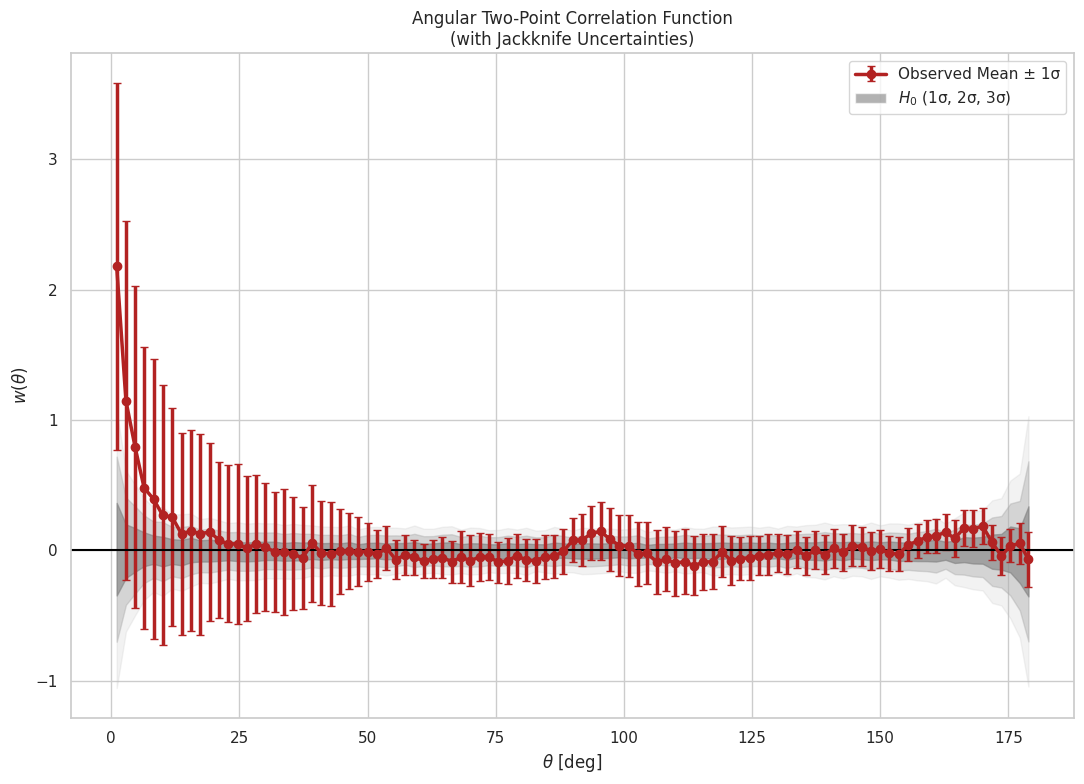

In [11]:
# ==============================================================
# 12. PLOT — 2pACF
# ==============================================================

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 8))

# H0 bands
ax.fill_between(theta, h0_mean - 3*h0_std, h0_mean + 3*h0_std,
                color='silver', alpha=0.2)
ax.fill_between(theta, h0_mean - 2*h0_std, h0_mean + 2*h0_std,
                color='darkgray', alpha=0.4)
ax.fill_between(theta, h0_mean - h0_std, h0_mean + h0_std,
                color='gray', alpha=0.6)

# Observed
ax.errorbar(theta, mean_w_obs, yerr=jk["err_w"],
            fmt='o-', color='firebrick',
            lw=2.5, capsize=3,
            label='Observed Mean ± 1σ')

ax.axhline(0, color='black')

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$w(\theta)$')

ax.set_title('Angular Two-Point Correlation Function\n(with Jackknife Uncertainties)')

# Legend
h0_patch = Patch(facecolor='gray', alpha=0.6,
                 label=r'$H_0$ (1σ, 2σ, 3σ)')

handles, labels = ax.get_legend_handles_labels()
handles.append(h0_patch)
labels.append(r'$H_0$ (1σ, 2σ, 3σ)')

ax.legend(handles, labels)

plt.tight_layout()
plt.savefig("FRB_2PACF_final.png", dpi=300)
plt.show()

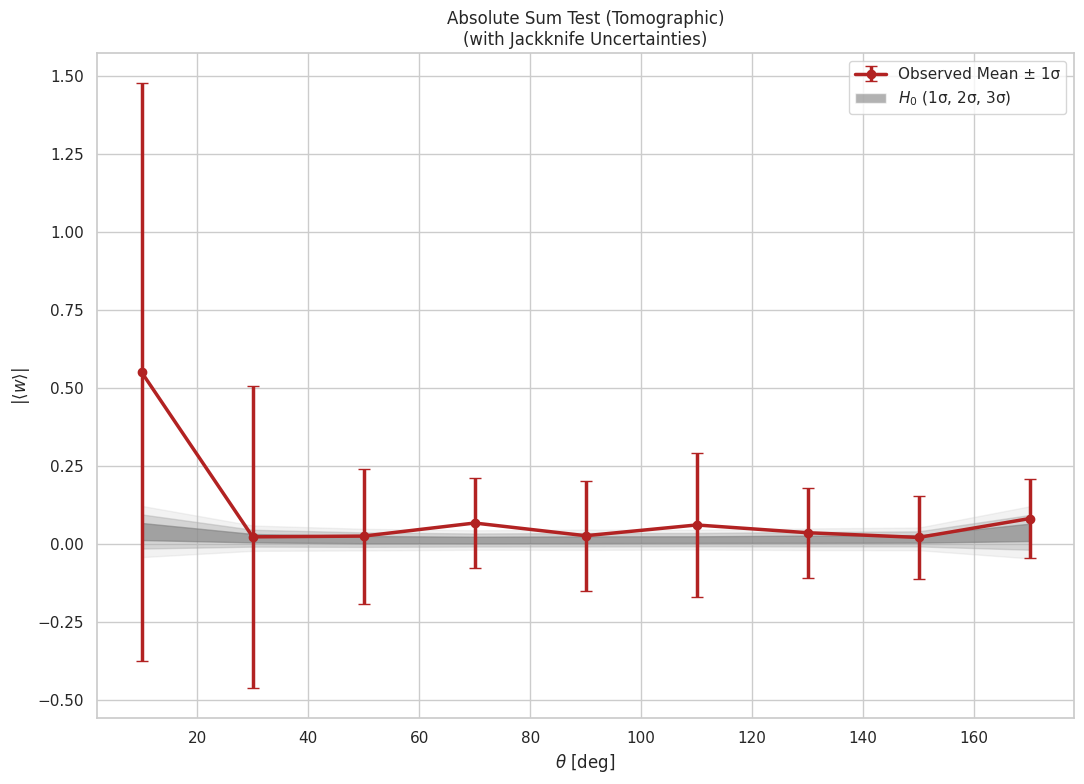

In [12]:
# ==============================================================
# 13. PLOT — ABSOLUTE SUM
# ==============================================================

fig, ax = plt.subplots(figsize=(11, 8))

ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - 3*h0_abs_std,
                h0_abs_mean + 3*h0_abs_std,
                color='silver', alpha=0.2)

ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - 2*h0_abs_std,
                h0_abs_mean + 2*h0_abs_std,
                color='darkgray', alpha=0.4)

ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - h0_abs_std,
                h0_abs_mean + h0_abs_std,
                color='gray', alpha=0.6)

ax.errorbar(COARSE_CENTERS, mean_abs_obs,
            yerr=jk["err_abs"],
            fmt='o-', color='firebrick',
            lw=2.5, capsize=4,
            label='Observed Mean ± 1σ')

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$|\langle w \rangle|$')

ax.set_title('Absolute Sum Test (Tomographic)\n(with Jackknife Uncertainties)')

h0_patch = Patch(facecolor='gray', alpha=0.6,
                 label=r'$H_0$ (1σ, 2σ, 3σ)')

handles, labels = ax.get_legend_handles_labels()
handles.append(h0_patch)
labels.append(r'$H_0$ (1σ, 2σ, 3σ)')

ax.legend(handles, labels)

plt.tight_layout()
plt.savefig("FRB_ABS_final.png", dpi=300)
plt.show()